# Performance Drop Detector

Imagine you have data

|Period|Campaign|Impr|Clicks|Cost|Conv|CPA|Revenue|ROAS|
|---|---|---|---|---|---|---|---|---|
|Period A|Campaign A|1000|100|500|30|16.7|1500|300%|
|Period B|Campaign A|1000|100|500|25|20|1200|240%|

From this point you can easily understand Period B was worse and something happened to Campaign A. But If you want to dig deeper and for example see performance by countries?

| Period | Campaign | Country | Impr | Clicks | Cost | Conv | CPA | Revenue | ROAS |
|------|------|------|------|------|------|------|------|------|------|
| Period A | Campaign A | US | 400 | 40 | 200 | 10 | 20 | 600 | 300% |
| Period A | Campaign A | UK | 300 | 30 | 150 | 10 | 15 | 450 | 300% |
| Period A | Campaign A | GE | 300 | 30 | 150 | 10 | 15 | 450 | 300% |
| Period B | Campaign A | US | 400 | 40 | 200 | 10 | 20 | 600 | 300% |
| Period B | Campaign A | UK | 300 | 30 | 150 | 10 | 15 | 450 | 300% |
| Period B | Campaign A | GE | 300 | 30 | 150 | 5 | 30 | 150 | 100% |

Or a more realistic example?

| Period | Campaign | Country | Impr | Clicks | Cost | Conv | CPA | Revenue | ROAS |
|------|------|------|------|------|------|------|------|------|------|
| Period A | Campaign A | US | 405 | 41 | 202 | 10 | 20.2 | 600 | 297% |
| Period A | Campaign A | UK | 295 | 29 | 148 | 10 | 14.8 | 450 | 304% |
| Period A | Campaign A | GE | 300 | 31 | 150 | 10 | 15 | 450 | 300% |
| Period B | Campaign A | US | 398 | 39 | 198 | 10 | 19.8 | 600 | 303% |
| Period B | Campaign A | UK | 305 | 31 | 152 | 10 | 15.2 | 450 | 296% |
| Period B | Campaign A | GE | 297 | 30 | 149 | 5 | 29.8 | 150 | 101% |

Not so easily, doesn't it? Germany brought less conversion with a lower ROAS. 

And finally, let's add another dimension like keywords

| Period | Campaign | Country | Keyword | Impr | Clicks | Cost | Conv | CPA | Revenue | ROAS |
|------|------|------|------|------|------|------|------|------|------|------|
| Period A | Campaign A | US | KW1 | 205 | 21 | 102 | 5 | 20.4 | 300 | 294% |
| Period A | Campaign A | US | KW2 | 200 | 20 | 100 | 5 | 20.0 | 300 | 300% |
| ... | ... | ... | ... | ... | ... | ... | ... | ... | ... | ... |
| Period B | Campaign A | GE | KW1 | 150 | 15 | 75 | 3 | 25.0 | 90 | 120% |
| Period B | Campaign A | GE | KW2 | 147 | 15 | 74 | 2 | 37.0 | 60 | 81% |

It's not realistic to compare without extra tools. However, here we don't want to predict anything or conduct an A/B test. We simply want to find one or multiple dimensions that affected performance.

Logistic regression is something that can help us. We can take one metric and measure whether a lower or higher value of this metric makes it more likely that it belongs to Period A or Period B. Also, we want to see the size of the effect so we can find anomaly dimension.

In easy words we want to run a series of comparisons like

| Period | Campaign | Country | Keyword | Conv | Difference |
|---|---|---|---|---|---|
|Period A|Campaign A| US | KW1 | 10 | 200% |
|Period B|Campaign A| US | KW1 | 20 | -  |

Logistic Regression is just a tool to make it possible.

## Getting Started

### 1. Install Anaconda
Anaconda is a free tool that lets you run Python notebooks like this one without any coding setup.

1. Go to [anaconda.com/download](https://www.anaconda.com/download)
2. Download the version for your operating system (Windows / Mac / Linux)
3. Run the installer and follow the steps (default settings are fine)
4. Once installed, open **Anaconda Navigator** from your Start Menu or Applications folder
5. Click **Launch** under **JupyterLab** or **Jupyter Notebook**

---

### 2. Install Required Libraries
Before running the notebook for the first time, open a **Terminal** (Mac/Linux) or **Anaconda Prompt** (Windows) and run:
```bash
pip install pandas scikit-learn matplotlib seaborn
```

---

### 3. How to Use This Notebook

1. **Open the notebook** — In Jupyter, navigate to the folder where you saved this file and click on it
2. **Load your data** — Replace the sample CSV file path with your own data file
3. **Label your periods** — In the configuration cell, mark which dates are `"Good"` and which are `"Bad"`
4. **Choose your dimensions** — Select which columns to analyze (e.g. country, account, channel)
5. **Choose your metric** — Pick the metric you want to investigate (e.g. cost, conversions, revenue)
6. **Run all cells** — Click **Kernel → Restart & Run All** from the top menu
7. **Read the chart** — Bars pointing in the "Bad" direction are your suspects. Start investigating the longest ones first
8. **Iterate** — If one dimension dominates, remove it and re-run to uncover secondary issues

#### Import Required Libraries

In [2]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt

This dataset was generated based on real data and contains the next columns:

|Column|Description|
|---|---|
|date|This is some date range you want to compare. It can be month-to-month or day-to-day. You can even include multible date ranges. Note you need to mark them as "Bad" or "Good" to analyze performance drop|
|country, account_id, ppc_manager, channel|These are the dimensions you want to check. You can use any dimension combinations here|
|impressions, clicks, cost, conversions, conv value|These are the metrics you want to compare. You can use any metric and also calculate them afterwards|

In [45]:
df = pd.read_csv('new_input.csv')
df.head()

,date,country,account_id,ppc_manager,channel,impressions,clicks,cost,conversions,conv value
0,period 0,country 0,account 0,manager 0,channel 0,47.0,3.0,0.0000,0.0,0.000000
1,period 0,country 0,account 1,manager 1,channel 1,0.0,0.0,0.0000,3.0,0.029010
2,period 0,country 1,account 2,manager 0,channel 2,9.0,3.0,0.0000,0.0,0.000000
3,period 0,country 1,account 2,manager 0,channel 3,144.0,0.0,0.0000,0.0,0.000000
4,period 0,country 1,account 3,manager 2,channel 2,16.0,13.0,0.1884,3.0,0.430059


You need to mark "Bad" and "Good" period in a dictionary

In [4]:
bad_good_map = {
    'period 0':'Good',
    'period 1':'Bad'
}

Let's see the number of dimensions you need to analyze to find the performance drop

In [47]:
print('Countries',len(df.country.unique()))
print('Accounts',len(df.account_id.unique()))
print('Channels',len(df.channel.unique()))

Countries 230
Accounts 161
Channels 13


And the total number of rows for 2 periods

In [48]:
len(df)

55576

This function analyzes which factors (dimensions) are most associated with a Good or Bad period.

First, the function reorganizes the data so that each date becomes a row, and every unique combination of the selected dimensions becomes its own column. The values inside these columns represent the selected metric (for example revenue, installs, or spend).

Next, each date is labeled as Good or Bad using a predefined mapping.

The function then applies logistic regression, a statistical method that estimates how strongly each feature influences the probability that a date belongs to a Good or Bad period.

The result of logistic regression is a set of coefficients (slopes):
- A positive slope means that higher values of this metric make it more likely the period is Bad.
- A negative slope means that higher values make it more likely the period is Good.
- Slopes close to zero mean the feature has little impact.

To make the results easier to interpret, the function:
- Selects the 10 most positive slopes (strongest signals of Bad periods)
- Selects the 10 most negative slopes (strongest signals of Good periods)
- Visualizes them in a bar chart.

Finally, it returns the underlying data for the most influential features, allowing further inspection of how these metrics behaved across dates.

In [36]:
def logistic_coef_multiindex(df, dimensions, metric):    
    """
    dimensions: str or list of columns to pivot on
    """
    if isinstance(dimensions, str):
        dimensions = [dimensions]

    # Aggregate
    df_agg = df[['date'] + dimensions + [metric]].groupby(['date'] + dimensions).sum().reset_index()

    # Pivot
    df_pivot = df_agg.pivot_table(
        index='date',
        columns=dimensions,
        values=metric,
        fill_value=0
    ).reset_index()

    # Flatten MultiIndex columns if multiple dimensions
    if isinstance(df_pivot.columns, pd.MultiIndex):
        df_pivot.columns = ['_'.join([str(c) for c in col if c]) for col in df_pivot.columns]

    # Convert target to binary
    # Replace with your actual mapping
    df_pivot["Monday_bin"] = df_pivot["date"].map(bad_good_map)
    df_pivot["Monday_bin"] = df_pivot["Monday_bin"].map({"Good": 0, "Bad": 1})

    X = df_pivot.drop(columns=["date", "Monday_bin"])
    y = df_pivot["Monday_bin"]

    # Logistic regression
    model = LogisticRegression(max_iter=1000)
    model.fit(X, y)

    # Coefficients
    coefficients = pd.Series(model.coef_[0], index=X.columns)

    # Sort coefficients
    coeff_sorted = coefficients.sort_values()
    top_negative = coeff_sorted.head(10)
    top_positive = coeff_sorted.tail(10)

    # Combine for visualization
    top_slopes = pd.concat([top_negative, top_positive])

    # Plot
    plt.figure(figsize=(12,6))
    sns.barplot(x=top_slopes.values, hue=top_slopes.index, palette='coolwarm')
    plt.axvline(0, color='black', linestyle='--')
    plt.title(f"Top 10 Positive and Negative Feature Slopes on {metric}")
    plt.xlabel("Slope (Coefficient)")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    # Return top 5 negative + top 5 positive columns (unique)
    cols_combined = list(top_negative.index[:5]) + list(top_positive.index[-5:])
    cols_unique = list(dict.fromkeys(cols_combined))
    df_pivot[cols_unique] = df_pivot[cols_unique].round(2)
    return df_pivot[["date"] + cols_unique]

Let's start with PPC Manager performance. It may actually be helpful to measure their impact

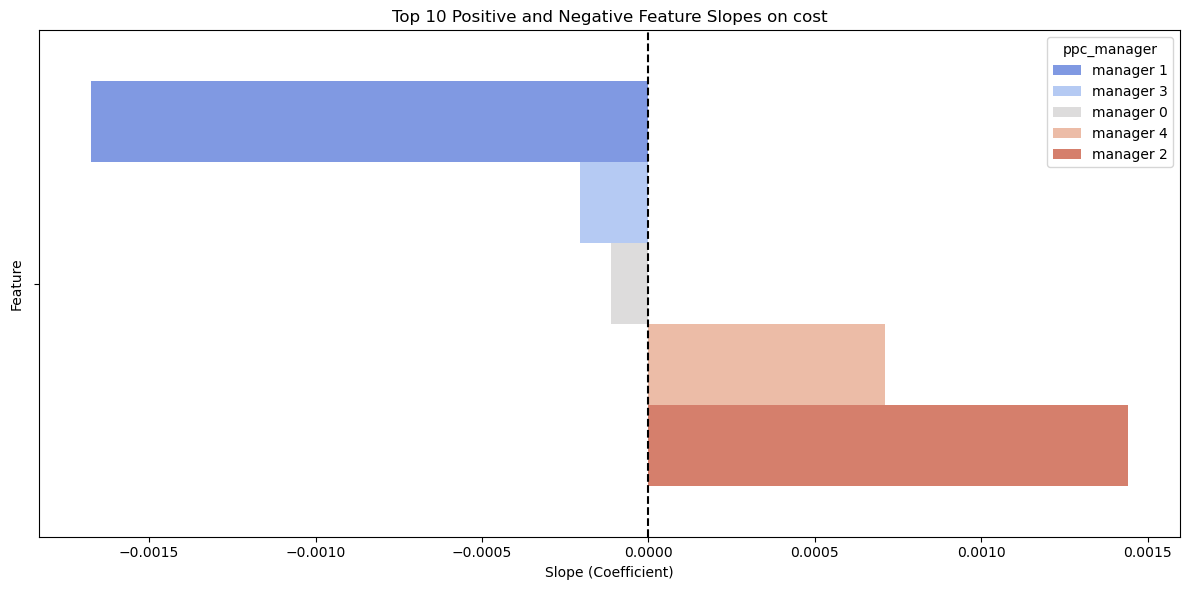

ppc_manager,date,manager 1,manager 3,manager 0,manager 4,manager 2
0,period 0,66442.27,4079.99,18328.31,17562.21,59784.78
1,period 1,66875.03,3464.24,20608.39,24803.80,78391.36


In [37]:
logistic_coef_multiindex(df, 'ppc_manager', 'cost')

Despite having an outlier **manager 2** who performed well during the Bad Period, their changes are not so 

Let's look at the country dimension and the cost metric. We can see the cost dropped significantly for **country 175**. There is also **country 177** performed much better in the Bad period

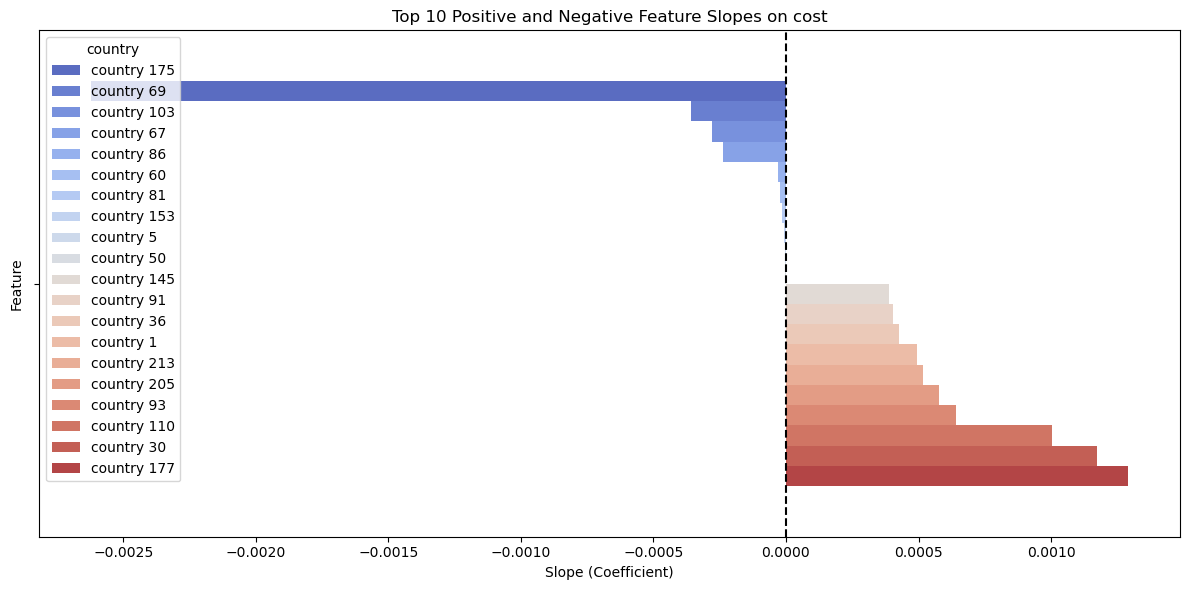

country,date,country 175,country 69,country 103,country 67,country 86,country 205,country 93,country 110,country 30,country 177
0,period 0,25500.44,5755.68,4264.12,3386.24,370.52,7231.80,756.43,2386.15,6789.56,4467.09
1,period 1,21206.24,5298.37,3896.05,3057.10,322.48,8922.88,2214.58,4734.49,9767.97,7570.92


In [38]:
logistic_coef_multiindex(df, 'country', 'cost')

Simillar can be applied to conv value. **country 175** is still suscpicious

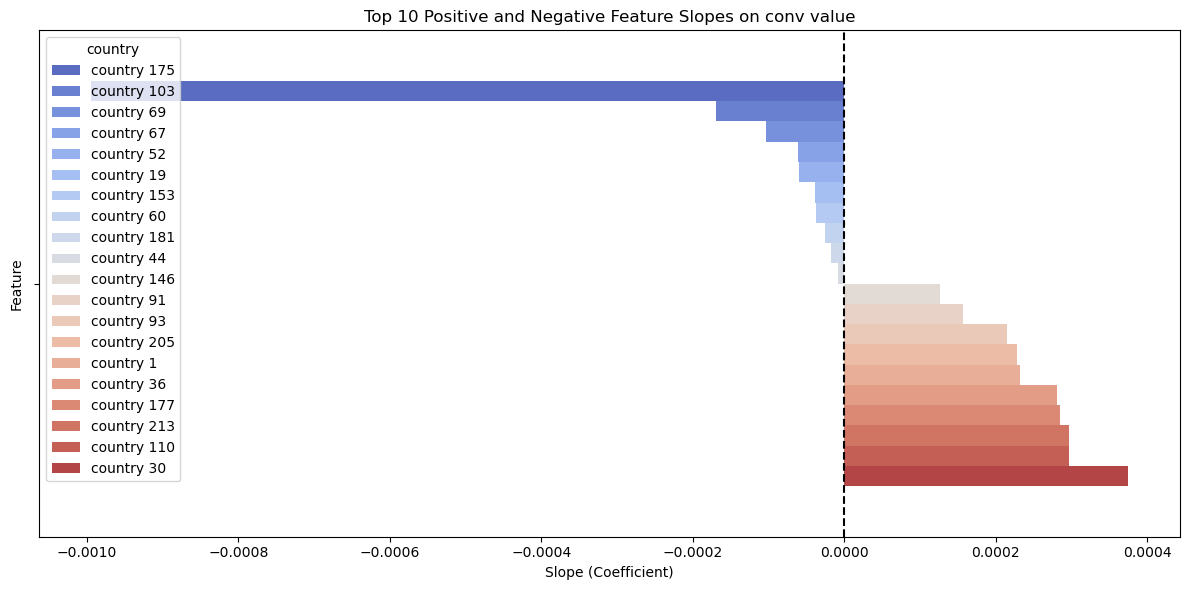

country,date,country 175,country 103,country 69,country 67,country 52,country 36,country 177,country 213,country 110,country 30
0,period 0,112426.26,19203.30,22969.27,14525.71,20370.35,11442.07,25701.31,210752.93,8674.98,26167.91
1,period 1,91548.56,15639.09,20520.40,13059.48,18781.94,16296.00,30294.06,211133.67,13898.77,32399.71


In [39]:
logistic_coef_multiindex(df, 'country', 'conv value')

And this is it, you're going to Executives saying **country 175** stopped bringing conversions, but maybe it's not a problem of a specific country. Imagine you have one huge project in this country and it failed. Let's check this too!

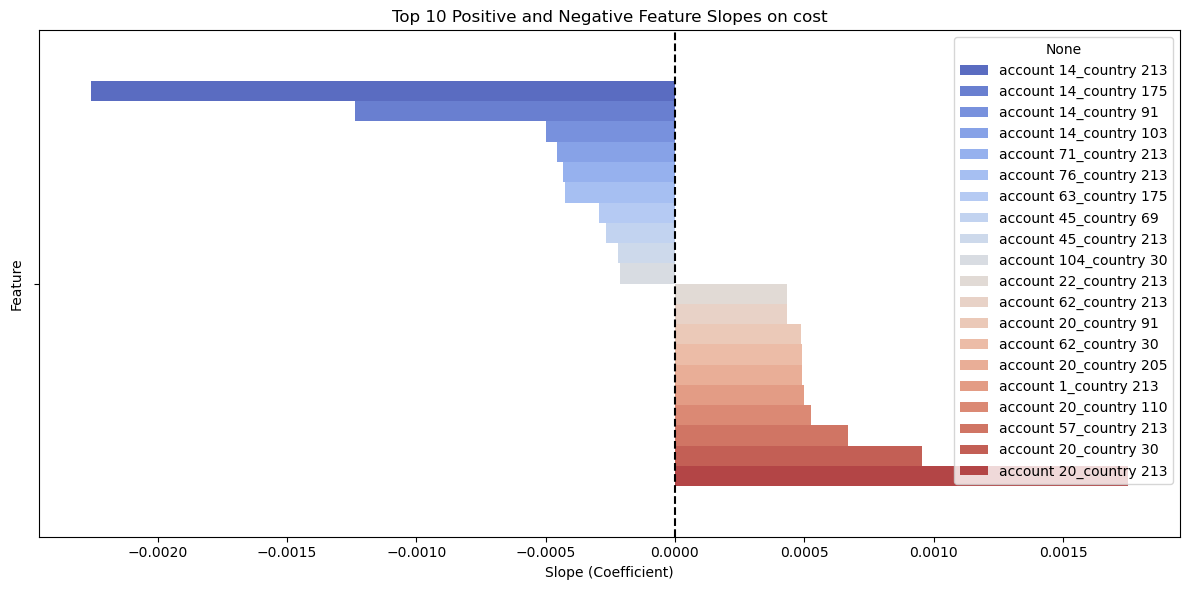

,date,account 14_country 213,account 14_country 175,account 14_country 91,account 14_country 103,account 71_country 213,account 1_country 213,account 20_country 110,account 57_country 213,account 20_country 30,account 20_country 213
0,period 0,8195.78,4692.10,1134.73,1392.28,786.26,403.55,340.06,792.91,1189.56,4926.03
1,period 1,4565.94,2699.52,337.68,659.15,96.34,1190.94,1169.40,1842.30,2689.41,7656.70


In [40]:
logistic_coef_multiindex(df, ['account_id','country'], 'cost')

You can see it's not the country problem, but one account stopped spending across many countries, and most likely, it's the main reason for the drop. Let's also check if **conv values** changed

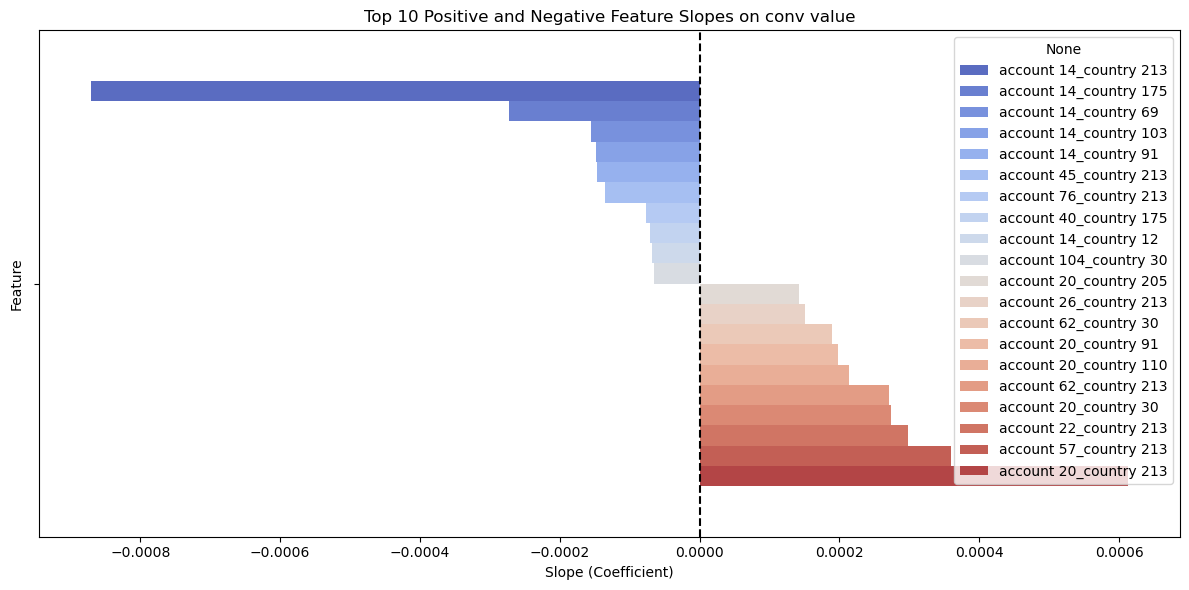

,date,account 14_country 213,account 14_country 175,account 14_country 69,account 14_country 103,account 14_country 91,account 62_country 213,account 20_country 30,account 22_country 213,account 57_country 213,account 20_country 213
0,period 0,32686.64,15630.56,3955.31,5384.43,3336.81,3257.15,4647.51,4493.62,4612.12,18696.47
1,period 1,17427.91,10171.53,1464.98,2817.07,1033.07,6340.95,7595.70,7777.67,8672.84,24255.75


In [41]:
logistic_coef_multiindex(df, ['account_id','country'], 'conv value')

We found it! **account 14** stopped spending and it resulted in a less conversion value. Finally let's look at channels if there are some drastic changes there

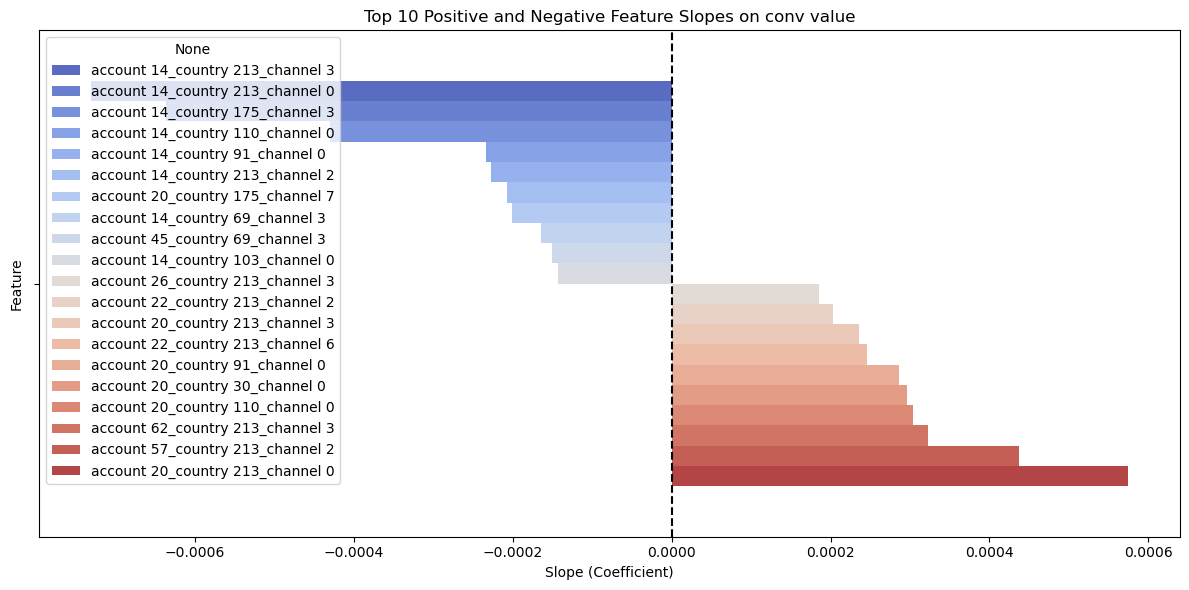

,date,account 14_country 213_channel 3,account 14_country 213_channel 0,account 14_country 175_channel 3,account 14_country 110_channel 0,account 14_country 91_channel 0,account 20_country 30_channel 0,account 20_country 110_channel 0,account 62_country 213_channel 3,account 57_country 213_channel 2,account 20_country 213_channel 0
0,period 0,12079.81,11135.05,9885.10,3447.24,2572.38,3266.71,980.26,1830.89,2039.61,9100.96
1,period 1,5546.34,5383.41,5762.48,1401.16,658.15,5111.47,3106.98,4005.42,5035.20,12405.67


In [42]:
logistic_coef_multiindex(df, ['account_id','country','channel'], 'conv value')

Well, **account 14** is still here. Bad boy!

But this may be only the beginning. Note that logistic regression analyzes relative values, and this huge anomaly may cover a smaller but still important problem. So let's drop it and repeat the analysis

In [43]:
df.columns

Index(['date', 'country', 'account_id', 'ppc_manager', 'channel',
       'impressions', 'clicks', 'cost', 'conversions', 'conv value'],
      dtype='object')

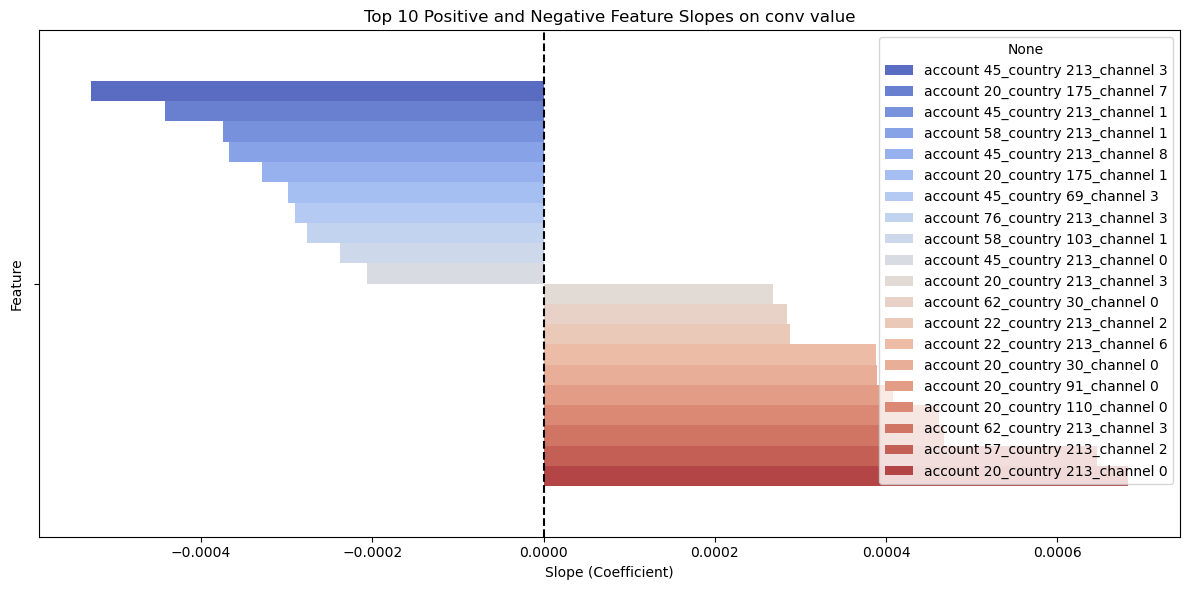

,date,account 45_country 213_channel 3,account 20_country 175_channel 7,account 45_country 213_channel 1,account 58_country 213_channel 1,account 45_country 213_channel 8,account 20_country 91_channel 0,account 20_country 110_channel 0,account 62_country 213_channel 3,account 57_country 213_channel 2,account 20_country 213_channel 0
0,period 0,15601.85,4639.09,8892.01,7861.11,9334.87,1907.06,980.26,1830.89,2039.61,9100.96
1,period 1,13506.22,2715.36,7364.20,6341.17,8021.06,3810.23,3106.98,4005.42,5035.20,12405.67


In [44]:
df = df[df['account_id']!='account 14']
logistic_coef_multiindex(df, ['account_id','country','channel'], 'conv value')

This time **account 45** dropped in performance

## Conclusion

Diagnosing a performance drop is straightforward when you have one or two campaigns to review. It becomes a completely different challenge when your data spans like in example across 230 countries, 161 accounts, and 13 channels - that's thousands of possible combinations to investigate.

This script solves exactly that problem. It automatically scans all dimensions at once and ranks which combinations are most likely responsible for a drop. Instead of spending days building pivot tables and comparing numbers manually, an analyst gets a clear, prioritized list of suspects in seconds.

The script works by comparing two time periods - a "Good" and a "Bad" one - across any dimensions and metrics you choose. It doesn't require any statistical background to use: you point it at your data, label your periods, and it tells you where to look first.

In this analysis, running the script across all dimension combinations immediately flagged a single account as the dominant cause of the drop. Removing it and re-running revealed a second, smaller issue underneath - something that would have been easy to miss in a manual review.

The approach is also flexible. The same script can be applied to any business with multi-dimensional performance data - not just PPC - and the number of dimensions is not limited to three. You can add or remove dimensions depending on what your data contains and what questions you need to answer.

## You can experiment with your data. Just fill the variables above with your values and see the result

In [ ]:
df = pd.read_csv('input.csv') #your input data
dimensions = ["country", "account_id", "channel"]  # add or remove as needed
metric = "conv value"                               # the metric to investigate
logistic_coef_multiindex(df, dimensions, metric)